# Use Case – Knowledge Graph Operational Restore

This notebook runs the same data and scenario as `Use_Case_sample.ipynb` but uses the
**graph-aware dependency path** to demonstrate that substations are correctly returned to
operational status after repair.  The key difference from the original notebook is:

1. `config['dependency_parameters']['knowledge_graph']` is populated with explicit rules
   for `msls`/`ms`/`ls` substations (loaded from the default knowledge graph).
2. `evaluate_dependencies_from_graph` performs a two-pass evaluate: **restore** eligible
   assets first, then **block** assets that still do not meet conditions.
3. A per-timestep diagnostic cell shows operational counts so the recovery is observable.

In [1]:
# HIDE CODE
# Imports
import sys
import time
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import geopandas as gpd
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import contextily as ctx

from src.adaptation import simulate_asset_damage_recovery_access_breakdown_ema
from config import get_config, get_development_config, setup_dev_directories, get_simulation_params
from src.simulation import simulate_asset_damage_recovery_access_breakdown 
from src.data_loader import load_hazard_maps, load_electricity_assets
from src.caching import load_simulation_caches
from pathlib import Path
from src.impacts import create_voronoi_for_asset_type, prepare_population_impact_data, prepare_land_use_impact_data, update_voll_rates, prepare_land_use_impact_data
import pickle
from src.visualisations import *
from ema_workbench import Model, RealParameter, IntegerParameter, Constant, TimeSeriesOutcome, SequentialEvaluator, Samplers, ema_logging, Policy

c:\Users\peregrin\AppData\Local\miniforge3\envs\miraca_template\Lib\site-packages\ema_workbench\em_framework\__init__.py:101: UserWarning: ipyparallel not installed - IpyparalleEvaluator not available
  warnings.warn("ipyparallel not installed - IpyparalleEvaluator not available")


In [2]:
# Set up configuration
config = get_development_config() #get_config() gets parameters directly from config.py in root, development config uses sample data
# config = get_config()
setup_dev_directories(config, remove_cache=False) # For a clean run, set remove_cache=True to clear all caches and start fresh
HAZARD_EXTRACTION_METHOD = config['analysis_config']['hazard_extraction_method']

# Configure simulation parameters from config
simulation_params = get_simulation_params(config) 
accessibility_model = None
simulation_params['accessibility_model'] = accessibility_model

print(f"\nSimulation configuration:")
for key, value in simulation_params.items():
    if key != 'config':  # Don't print the entire config
        print(f"  {key}: {value}")

print(f"\nDirectory structure:")
print(f"  Interim: {config['interim_dir']}")
print(f"  Output: {config['output_dir']}")
print(f"  Cache will be organized by hazard directory: {Path(config['hazard_dir']).name}")

# 6 for full data, 24 for sample data (which has 24 timesteps per day instead of 4)
config['simulation_config']['major_timestep'] = 24
# config['simulation_config']['major_timestep'] = 6
config['simulation_config']['verbose'] = False
max_days = None

caches = load_simulation_caches(config['interim_dir'], config['hazard_dir'])
print(f"Loaded caches: {[k for k in caches.keys() if caches[k] is not None]}")

root_dir = Path(config['root_dir'])
study_area_path = root_dir / 'data' / 'utilities' / 'stedin_area.geojson'
land_use_path = root_dir / 'data' / 'land_use' / 'CBS_Publicatiebestand_BBG2017_v1_sample.gpkg'
# land_use_path = root_dir / 'data' / 'land_use' / 'CBS_Publicatiebestand_BBG2017_v1.gpkg'
population_data_path = root_dir / "data" / "population" / "cbs_vk100_2024_v1_sample.gpkg"
# population_data_path = root_dir / "data" / "population" / "cbs_vk100_2024_v1.gpkg"

print(f"WARNING! Values of lost load should be calculated with country-wide VOLL rates, not sample data!")

# Cache path for asset_to_lu (the complete pre-computed lookup)
asset_to_lu_cache_path = config['interim_dir'] / f"{land_use_path.stem}_asset_to_lu.pkl"

Created directories: c:\repos\powerpath\data\interim\interim_test_hazard_timesteps, c:\repos\powerpath\data\output\output_test_hazard_timesteps

Simulation configuration:
  flood_threshold: 0.2
  number_repair_crews: 5
  repair_crew_assignment_method: islands
  verbose: True
  recovery_parameters: {'repair_time_coefficients': [702.72, 3.14, 1.9891], 'damage_ratio_coefficients': (0.0468, 0.0077), 'damage_threshold': 0.01, 'repair_threshold': 2.0}
  accessibility_model: None

Directory structure:
  Interim: c:\repos\powerpath\data\interim\interim_test_hazard_timesteps
  Output: c:\repos\powerpath\data\output\output_test_hazard_timesteps
  Cache will be organized by hazard directory: test_hazard_timesteps
Loading simulation caches...
No accessibility cache found at c:\repos\powerpath\data\interim\interim_test_hazard_timesteps\accessibility_cache_test_hazard_timesteps.pkl
No hazard extraction cache found at c:\repos\powerpath\data\interim\interim_test_hazard_timesteps\hazard_extraction_cac

Found 10 hazard map files


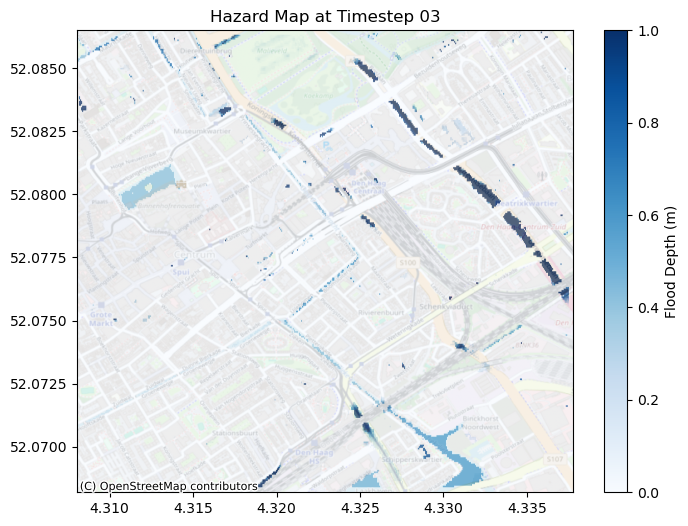

In [3]:
hazard_maps = load_hazard_maps(config['hazard_dir'], max_days=None)  
hazard_map_03 = hazard_maps[3]
with rasterio.open(hazard_map_03) as src:
    hazard_data_03 = src.read(1)
    hazard_transform_03  = src.transform
    crs = src.crs


from rasterio.plot import plotting_extent

fig, ax = plt.subplots(figsize=(8, 6))
extent = plotting_extent(hazard_data_03, hazard_transform_03)
im = ax.imshow(hazard_data_03, cmap='Blues', vmax=1, extent=extent, origin='upper', zorder=1)
ax.set_title("Hazard Map at Timestep 03")
fig.colorbar(im, ax=ax, label="Flood Depth (m)")

# Set axis to Web Mercator for contextily
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_aspect('auto')
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik, zoom=15, alpha=0.3,zorder=2)
plt.show()

Found 1 electricity station files matching types ['msls']
All .shp files in directory: ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp', 'ms_stations_test_samples.shp']
Files with 'station': ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp', 'ms_stations_test_samples.shp']
Final matched files: ['msls_stations_test_samples.shp']
Loading electricity assets from msls_stations_test_samples.shp
Loaded 245 msls assets
Combined total: 245 electricity assets
Asset types: {'msls': 245}


C:\Users\peregrin\AppData\Local\Temp\ipykernel_10808\1530913130.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_assets.centroid.to_crs(epsg=4326).plot(ax=ax, color='green',


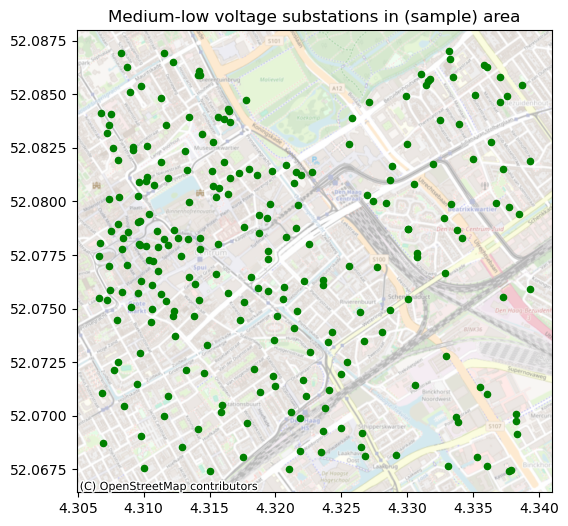

In [4]:
gdf_assets = load_electricity_assets(config['electricity_dir'], asset_types=['msls'])
fig, ax = plt.subplots(figsize=(8, 6))
gdf_assets.centroid.to_crs(epsg=4326).plot(ax=ax, color='green', 
                                        #    markersize=2)
                                          markersize=20)
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik, zoom=15, alpha=0.5)
plt.title("Medium-low voltage substations in (sample) area")
plt.show()

## Knowledge Graph Configuration

We load the default knowledge graph and inject it into the simulation config.
The graph encodes:

| Asset type | Return-to-operational trigger |
|---|---|
| `msls` | `repair_complete` – full repair must finish |
| `ms`   | `repair_complete` – full repair must finish |
| `ls`   | `repair_below 2h` – re-energised once remaining work < 2 hours |

This replaces the ad-hoc `state.operational[completed_repairs] = True` fix with a
principled, config-driven two-pass evaluation (restore then block).

In [ ]:
from src.dependency_knowledge_graph import build_default_knowledge_graph, TRIGGER_REPAIR_COMPLETE, TRIGGER_REPAIR_BELOW

kg = build_default_knowledge_graph()
print(f'Loaded knowledge graph with {len(kg)} rules')
for rule in kg._rules:
    rto = rule.return_to_operational
    desc = rto.trigger if rto.trigger != 'repair_below' else f'{rto.trigger} (threshold={rto.threshold}h)'
    print(f'  {rule.asset_type_a}: hazard_blocks={rule.hazard_blocks_operation}, return_to_operational={desc}')

# Inject knowledge graph rules into the simulation config so the graph-aware path is active.
# get_development_config() already populates this from config.py; this cell makes it explicit.
print(f"\nKnowledge graph rules in config: {len(config['dependency_parameters']['knowledge_graph'])} entries")
print(f"Hazard type: {config['dependency_parameters']['hazard_type']}")

## Single Simulation Run (graph-aware path)

We run the same simulation as the original notebook.  Because `dependency_parameters`
is now populated, `_update_operational_state` takes the graph-aware path:

1. **Restore pass**: re-enables substations that are no longer flooded and have
   completed (or sufficiently completed) repair.
2. **Block pass**: immediately re-suppresses any substation that is still flooded
   or whose repair trigger has not yet been met.

Both passes are driven by `evaluate_dependencies_from_graph` in `dependency_evaluator.py`.

In [ ]:
caches = load_simulation_caches(config['interim_dir'], config['hazard_dir'])

all_results, final_state, cache_updated = simulate_asset_damage_recovery_access_breakdown(
    gdf_assets,
    hazard_maps,
    number_repair_crews=5,
    repair_crew_assignment_method=simulation_params['repair_crew_assignment_method'],
    flood_threshold=simulation_params['flood_threshold'],
    recovery_parameters=simulation_params['recovery_parameters'],
    root_dir=config['root_dir'],
    verbose=False,
    timestep_output=True,
    execution_id='kg_run',
    config=config,
    major_timestep=config['simulation_config']['major_timestep'],
    accessibility_cache=caches.get('accessibility_cache', None),
    hazard_extraction_cache=caches.get('hazard_extraction_cache', None),
    overlap_cache=caches.get('overlap_cache', None),
    island_cache=caches.get('island_cache', None),
    fragility_param_k=6.0,
)
print('Simulation completed.')

In [ ]:
from src.visualisations import print_simulation_summary
results_df = pd.DataFrame(all_results[0][1])
print_simulation_summary(results_df, gdf_assets, config)

## Operational Restoration Diagnostic

The plot below shows the number of operational substations over time.
Under the graph-aware path, substations that are repaired and no longer flooded
should return to `operational = True`.  You should see the operational count
recover toward the total asset count as the flood recedes and repair crews finish.

If the count stays flat (never recovers), the restore pass is not working.
If it recovers, the two-pass design is functioning correctly.

In [ ]:
import matplotlib.pyplot as plt

num_assets = len(gdf_assets)
timestep_results = all_results[0][2]  # per-timestep detail records

if timestep_results:
    ts_df = pd.DataFrame(timestep_results)
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    # Operational count
    axes[0].plot(ts_df['timestep'], ts_df['operational_count'], label='Operational', color='green')
    axes[0].axhline(num_assets, color='gray', linestyle='--', label=f'Total ({num_assets})')
    axes[0].set_ylabel('Substation count')
    axes[0].set_title('Operational substations over time (graph-aware path)')
    axes[0].legend()
    axes[0].set_ylim(0, num_assets + 2)

    # Flooded count
    axes[1].plot(ts_df['timestep'], ts_df['flooded_count'], label='Flooded', color='blue')
    axes[1].set_ylabel('Substation count')
    axes[1].set_title('Flooded substations over time')
    axes[1].legend()

    # Repair crews assigned
    if 'crews_assigned_count' in ts_df.columns:
        axes[2].plot(ts_df['timestep'], ts_df['crews_assigned_count'], label='Crews assigned', color='orange')
        axes[2].set_ylabel('Count')
        axes[2].set_title('Repair crew assignments over time')
        axes[2].legend()

    axes[-1].set_xlabel('Timestep (hours)')
    plt.tight_layout()
    plt.show()

    # Tabular summary: first and last timestep where operational < total
    degraded = ts_df[ts_df['operational_count'] < num_assets]
    if degraded.empty:
        print('No substations lost operational status during the simulation.')
    else:
        print(f'Operational loss window: timestep {degraded["timestep"].min()} to {degraded["timestep"].max()}')
        print(f'Minimum operational count: {degraded["operational_count"].min()} / {num_assets}')
        recovered = ts_df[ts_df['timestep'] > degraded['timestep'].max()]
        if not recovered.empty and recovered['operational_count'].iloc[0] == num_assets:
            print('Full operational recovery confirmed.')
        elif not recovered.empty:
            print(f'Partial recovery: {recovered["operational_count"].max()} / {num_assets} at end.')
        else:
            print('NOTE: Simulation ended before full recovery – extend hazard_maps or increase repair crews.')
else:
    print('No timestep-level results available. Re-run with timestep_output=True.')

## Trigger Mode Comparison

The cell below shows which trigger mode governs each asset type present in the
simulation, and at each timestep whether that trigger condition was met for any
currently non-operational substation.  This makes the restore logic transparent.

In [ ]:
from src.dependency_knowledge_graph import build_default_knowledge_graph, TRIGGER_IMMEDIATE, TRIGGER_REPAIR_COMPLETE, TRIGGER_REPAIR_BELOW
import numpy as np

kg = build_default_knowledge_graph()
asset_types_present = gdf_assets['type'].unique() if 'type' in gdf_assets.columns else ['msls']
hazard_type = config['dependency_parameters']['hazard_type']

print('Return-to-operational trigger per asset type in this simulation:')
for at in asset_types_present:
    rules = kg.get_rules_or_default(hazard_type, at)
    for r in rules:
        rto = r.return_to_operational
        if rto.trigger == TRIGGER_IMMEDIATE:
            print(f'  {at}: IMMEDIATE – returns to operational as soon as hazard clears (no repair required)')
        elif rto.trigger == TRIGGER_REPAIR_COMPLETE:
            print(f'  {at}: REPAIR_COMPLETE – returns to operational only when repair_time == 0')
        elif rto.trigger == TRIGGER_REPAIR_BELOW:
            print(f'  {at}: REPAIR_BELOW {rto.threshold}h – returns when repair_time < {rto.threshold}h')

# Show final state
print(f'\nFinal state summary:')
print(f'  Operational: {final_state["operational"].sum()} / {len(final_state["operational"])}')
print(f'  Damage ratio > 0: {(final_state["damage_ratio"] > 0).sum()}')
print(f'  Repair time > 0: {(final_state["repair_time"] > 0).sum()}')